# STEP 07 — PPO & Continuous Battery Control

A DQN továbbra is három diszkrét action között választ. Egy valódi inverter viszont nem csak `-30 / 0 / +30 kW` értéket tud kérni. Ebben a notebookban continuous action space-re váltunk: `[-1, 1]`, ahol az action a rendelkezésre álló charge/discharge power aránya.

In [1]:
from pathlib import Path
import sys, json, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

ROOT = Path.cwd()
if ROOT.name == "workflow":
    ROOT = ROOT.parent
SRC = ROOT / "src"
for p in [ROOT, SRC]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from workflow.shared.utils import ensure_data, load_config, build_env

cfg = load_config()
full, train, val, test = ensure_data()
FIG_DIR = ROOT / "04_results" / "figures"
METRIC_DIR = ROOT / "04_results" / "metrics"
MODEL_DIR = ROOT / "04_results" / "models"
PRED_DIR = ROOT / "04_results" / "predictions"
for p in [FIG_DIR, METRIC_DIR, MODEL_DIR, PRED_DIR]:
    p.mkdir(parents=True, exist_ok=True)

QUICK_MODE = True  # GitHub notebookhoz gyors futás. Komolyabb benchmarkhoz állítsd False-ra.
SEEDS = [42, 123, 2026]
print(f"Project root: {ROOT}")
print(f"Rows: full={len(full):,}, train={len(train):,}, validation={len(val):,}, test={len(test):,}")

Project root: /mnt/data/smart_battery_energy_management_rl
Rows: full=8,760, train=6,132, validation=1,314, test=1,314


## 1. Continuous action mapping

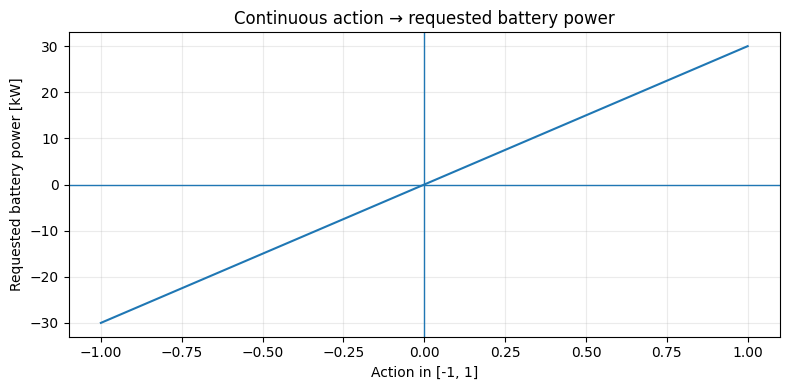

In [2]:
env = build_env(train, cfg, continuous=True, random_start=True)
actions = np.linspace(-1, 1, 101)
powers = np.where(actions >= 0, actions * env.spec.max_charge_kw, actions * env.spec.max_discharge_kw)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(actions, powers)
ax.axhline(0, linewidth=1); ax.axvline(0, linewidth=1)
ax.set_title("Continuous action → requested battery power")
ax.set_xlabel("Action in [-1, 1]"); ax.set_ylabel("Requested battery power [kW]"); ax.grid(alpha=0.25)
fig.tight_layout(); fig.savefig(FIG_DIR / "nb07_01_continuous_action_mapping.png", dpi=170, bbox_inches="tight")
plt.show()

Negatív action = discharge, pozitív = charge. Az environment ezután ugyanúgy alkalmazza a SOC- és power-korlátokat, tehát a continuous policy sem tud fizikailag lehetetlen állapotot létrehozni.

## 2. PPO: actor + critic

A PPO policy-gradient módszer. Az **actor** egy action distributiont tanul, a **critic** pedig a state value `V(s)` becslését. A critic segít meghatározni az advantage-et: mennyivel volt jobb vagy rosszabb a tapasztalt action annál, amit az adott state-ben általában várnánk.

In [3]:
import torch
from battery_rl.agents.ppo_torch import ContinuousActorCritic, TorchPPOAgent, train_ppo
from battery_rl.evaluation import evaluate_policy

model = ContinuousActorCritic(observation_dim=len(env.obs_columns))
print(model)
print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

ContinuousActorCritic(
  (actor_body): Sequential(
    (0): Linear(in_features=5, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): Tanh()
  )
  (actor_mean): Linear(in_features=128, out_features=1, bias=True)
  (critic): Sequential(
    (0): Linear(in_features=5, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): Tanh()
    (4): Linear(in_features=128, out_features=1, bias=True)
  )
)
Trainable parameters: 34819


## 3. Policy output egy observationre

In [4]:
obs, _ = env.reset(seed=42)
x = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
with torch.no_grad():
    dist = model.distribution(x)
    value = model.value(x)
print("Gaussian mean before tanh:", float(dist.mean.item()))
print("Gaussian std:", float(dist.stddev.item()))
print("Critic V(s):", float(value.item()))
print("Deterministic action after tanh:", float(torch.tanh(dist.mean).item()))

Gaussian mean before tanh: -0.2519705891609192
Gaussian std: 0.6065306663513184
Critic V(s): -0.1816062331199646
Deterministic action after tanh: -0.24677014350891113


## 4. PPO clipped objective — miért „Proximal”?

A PPO nem engedi, hogy egy minibatch túl nagyot változtasson a policy-n. Az új/old log-probability arányt `r(θ)` a `[1-ε, 1+ε]` tartományban klippeli a surrogate objective egyik ágában.

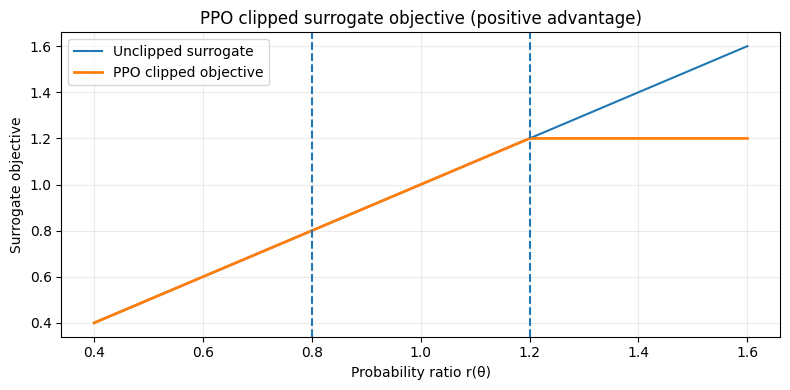

In [5]:
ratio = np.linspace(0.4, 1.6, 300)
adv_pos = 1.0
clip = float(cfg["ppo"]["clip_coef"])
unclipped = ratio * adv_pos
clipped = np.clip(ratio, 1-clip, 1+clip) * adv_pos
objective = np.minimum(unclipped, clipped)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ratio, unclipped, label="Unclipped surrogate")
ax.plot(ratio, objective, label="PPO clipped objective", linewidth=2)
ax.axvline(1-clip, linestyle="--"); ax.axvline(1+clip, linestyle="--")
ax.set_title("PPO clipped surrogate objective (positive advantage)")
ax.set_xlabel("Probability ratio r(θ)"); ax.set_ylabel("Surrogate objective"); ax.legend(); ax.grid(alpha=0.25)
fig.tight_layout(); fig.savefig(FIG_DIR / "nb07_02_ppo_clipped_objective.png", dpi=170, bbox_inches="tight")
plt.show()

## 5. GAE — Generalized Advantage Estimation

A GAE a TD hibák diszkontált kombinációjával becsüli az advantage-et. A `λ` bias–variance trade-offot szabályoz: kisebb érték rövidebb horizontú, stabilabb; nagyobb érték több jövőbeli információt használ.

## 6. PPO training PyTorch-tal

In [6]:
pcfg = cfg["ppo"]
steps = 2500 if QUICK_MODE else int(pcfg["timesteps"])
ppo = TorchPPOAgent(
    observation_dim=len(env.obs_columns), learning_rate=pcfg["learning_rate"], gamma=pcfg["gamma"],
    gae_lambda=pcfg["gae_lambda"], clip_coef=pcfg["clip_coef"], value_coef=pcfg["value_coef"],
    entropy_coef=pcfg["entropy_coef"], update_epochs=3 if QUICK_MODE else pcfg["update_epochs"],
    minibatch_size=pcfg["minibatch_size"], seed=42,
)
history = train_ppo(env, ppo, total_timesteps=steps, rollout_steps=min(256, pcfg["rollout_steps"]), seed=42)
ppo.save(MODEL_DIR / "ppo_torch_seed_42.pt")
print("Finished episodes:", len(history.episode_returns), "PPO minibatch updates:", len(history.policy_losses))

Finished episodes: 104 PPO minibatch updates: 120


## 7. Episode return

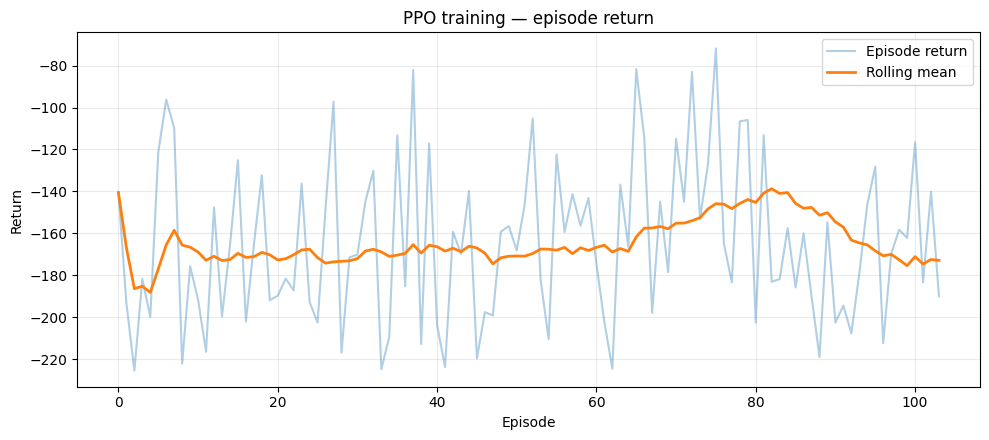

In [7]:
ret = pd.Series(history.episode_returns)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(ret, alpha=0.35, label="Episode return")
ax.plot(ret.rolling(20, min_periods=1).mean(), linewidth=2, label="Rolling mean")
ax.set_title("PPO training — episode return")
ax.set_xlabel("Episode"); ax.set_ylabel("Return"); ax.legend(); ax.grid(alpha=0.25)
fig.tight_layout(); fig.savefig(FIG_DIR / "nb07_03_ppo_return.png", dpi=170, bbox_inches="tight")
plt.show()

## 8. Policy és value loss

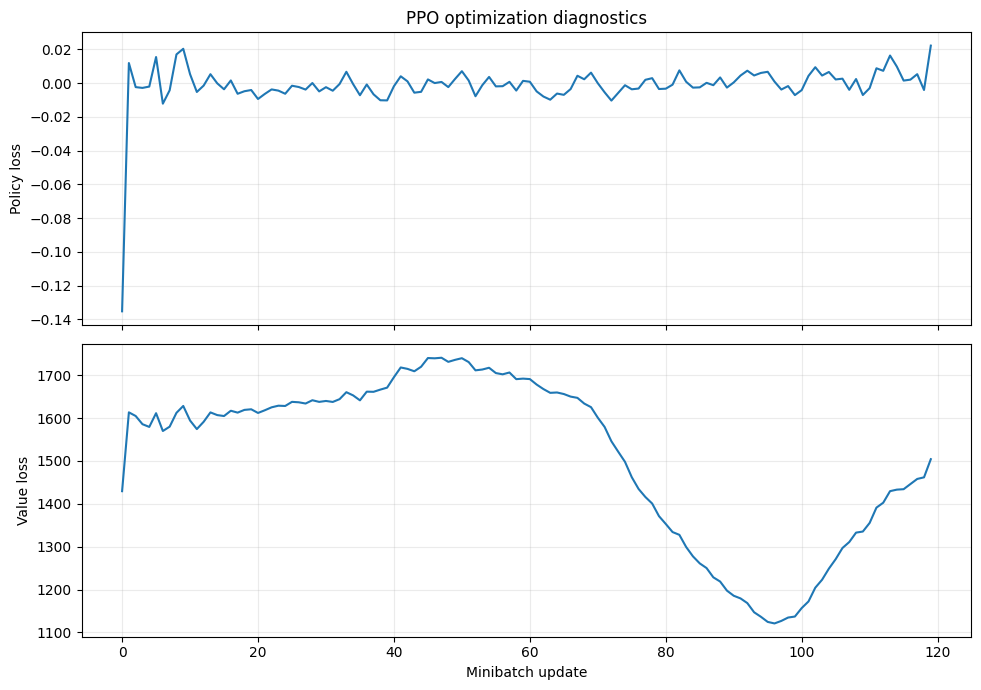

In [8]:
pl = pd.Series(history.policy_losses); vl = pd.Series(history.value_losses)
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
axes[0].plot(pl.rolling(30, min_periods=1).mean()); axes[0].set_ylabel("Policy loss")
axes[1].plot(vl.rolling(30, min_periods=1).mean()); axes[1].set_ylabel("Value loss"); axes[1].set_xlabel("Minibatch update")
axes[0].set_title("PPO optimization diagnostics")
for ax in axes: ax.grid(alpha=0.25)
fig.tight_layout(); fig.savefig(FIG_DIR / "nb07_04_ppo_losses.png", dpi=170, bbox_inches="tight")
plt.show()

## 9. Entropy és approximate KL

Az entropy az exploration egyik indikátora. Az approximate KL azt jelzi, mekkorát mozdult a policy update során. Ezek diagnosztikai metrikák, nem üzleti KPI-k.

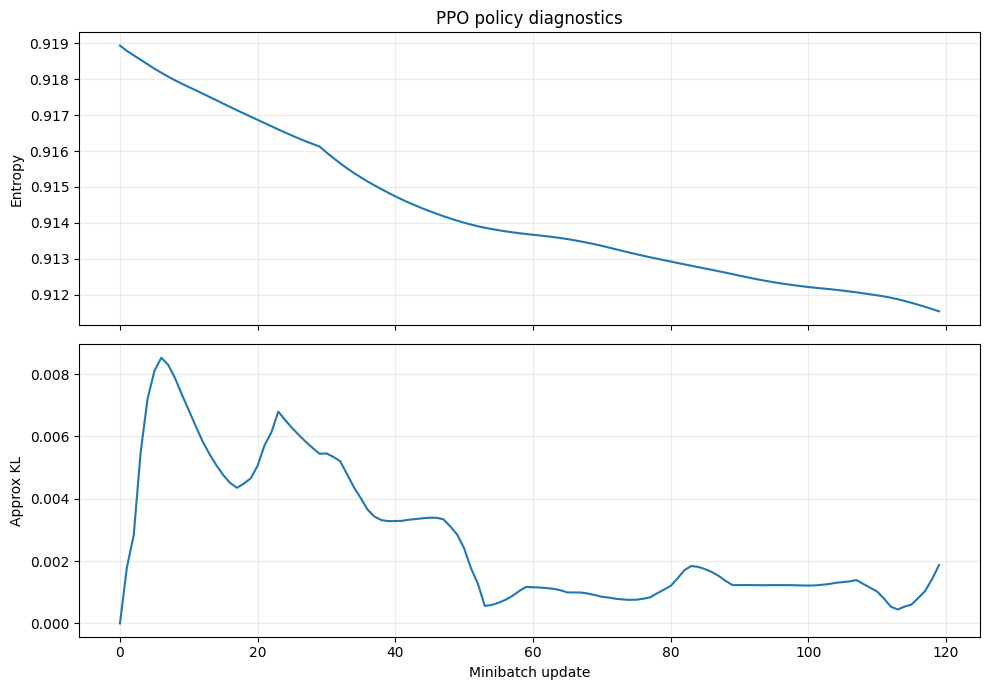

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
axes[0].plot(pd.Series(history.entropies).rolling(30, min_periods=1).mean()); axes[0].set_ylabel("Entropy")
axes[1].plot(pd.Series(history.approx_kls).rolling(30, min_periods=1).mean()); axes[1].set_ylabel("Approx KL"); axes[1].set_xlabel("Minibatch update")
axes[0].set_title("PPO policy diagnostics")
for ax in axes: ax.grid(alpha=0.25)
fig.tight_layout(); fig.savefig(FIG_DIR / "nb07_05_ppo_entropy_kl.png", dpi=170, bbox_inches="tight")
plt.show()

## 10. Validation és test evaluation

In [10]:
val_metrics, _ = evaluate_policy(lambda: build_env(val, cfg, continuous=True, random_start=True), ppo, seeds=SEEDS, episodes=6 if QUICK_MODE else 20)
test_metrics, ppo_logs = evaluate_policy(lambda: build_env(test, cfg, continuous=True, random_start=True), ppo, seeds=SEEDS, episodes=6 if QUICK_MODE else 20)
ppo_summary = pd.DataFrame({"validation_mean":val_metrics.mean(numeric_only=True), "test_mean":test_metrics.mean(numeric_only=True), "test_std":test_metrics.std(numeric_only=True)})
display(ppo_summary)
val_metrics.to_csv(METRIC_DIR / "step07_ppo_validation_metrics.csv", index=False)
test_metrics.to_csv(METRIC_DIR / "step07_ppo_test_metrics.csv", index=False)
ppo_logs.to_csv(PRED_DIR / "step07_ppo_seed_42_logs.csv", index=False)

,validation_mean,test_mean,test_std
total_electricity_cost,126.735324,96.724898,17.719550
peak_grid_demand_kw,68.283559,63.006269,8.418889
renewable_self_consumption_pct,92.170264,75.914423,5.180868
battery_throughput_kwh,48.181851,48.110337,0.270270
battery_cycles,0.200758,0.200460,0.001126
constraint_violations,14.500000,14.833333,2.786874
average_soc,0.168500,0.165432,0.022767
cumulative_reward,-131.518146,-101.121227,18.004930
episode_return,-131.518146,-101.121227,18.004930


## 11. Continuous policy action és SOC egy representative episode-ban

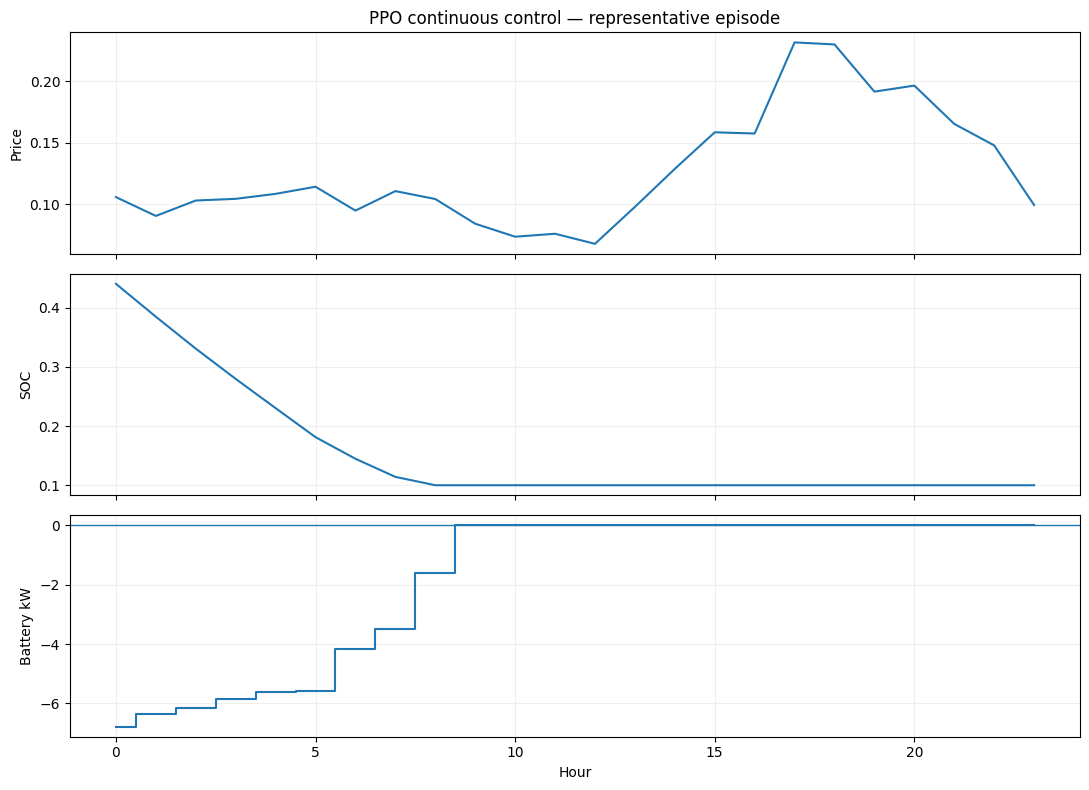

In [11]:
ep = ppo_logs[ppo_logs.episode == 0].copy()
x = np.arange(len(ep))
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
axes[0].plot(x, ep.price); axes[0].set_ylabel("Price")
axes[1].plot(x, ep.soc); axes[1].set_ylabel("SOC")
axes[2].step(x, ep.executed_battery_power_kw, where="mid"); axes[2].axhline(0, linewidth=1); axes[2].set_ylabel("Battery kW"); axes[2].set_xlabel("Hour")
axes[0].set_title("PPO continuous control — representative episode")
for ax in axes: ax.grid(alpha=0.2)
fig.tight_layout(); fig.savefig(FIG_DIR / "nb07_06_ppo_episode.png", dpi=170, bbox_inches="tight")
plt.show()

## 12. Continuous action distribution

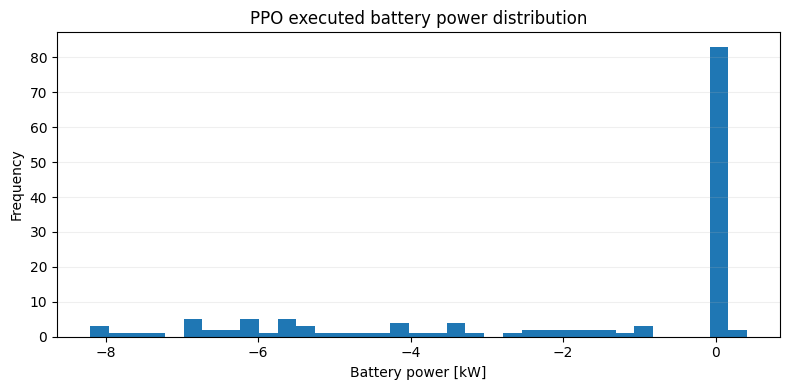

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ppo_logs.executed_battery_power_kw, bins=35)
ax.set_title("PPO executed battery power distribution")
ax.set_xlabel("Battery power [kW]"); ax.set_ylabel("Frequency"); ax.grid(axis="y", alpha=0.2)
fig.tight_layout(); fig.savefig(FIG_DIR / "nb07_07_ppo_action_distribution.png", dpi=170, bbox_inches="tight")
plt.show()

## DQN vs PPO gondolkodás

DQN diszkrét actionre természetes: három külön Q-értéket becsül. PPO közvetlenül continuous policy distributiont tanul, így finomabb teljesítményszabályozást ad. Ez azonban nem jelenti automatikusan, hogy jobb KPI-t ér el — ezt a következő notebookban azonos energetikai metrikák alapján hasonlítjuk össze.